---
title: "Non-stationary GEV — spatial GPs on the tail parameters too"
---

# Annual temperature extremes over Spain — part 3: location-dependent tails

Direct follow-up to [02_spain_multiplicative](02_spain_multiplicative.ipynb). Same Iberian grid, same GMST-driven trend, same block-maxima setup — but now we let the **GEV scale $\sigma$ and shape $\xi$** vary across space too. That moves the last two remaining globals out of the likelihood and into the GP prior.

nb 02 parameterised

$$y(s, t) \sim \mathrm{GEV}\bigl(\tau(s, t),\, \sigma,\, \xi\bigr), \qquad \tau(s, t) = \mu(s) + \beta(s) \cdot d(t),$$

with $\sigma, \xi$ shared across all 40 stations. This notebook generalises the likelihood to

$$y(s, t) \sim \mathrm{GEV}\bigl(\tau(s, t),\, \sigma(s),\, \xi(s)\bigr),$$

so that tail heaviness and dispersion are per-location — the right modelling choice when a domain spans distinct climate regimes (here: Atlantic NW, continental interior, Mediterranean SE), each with its own extreme-value statistics.

The price is a latent state with **four parallel spatial GPs** ($\mu, \tilde\beta, \tilde\sigma, \tilde\xi$) and a **three-dimensional Gauss–Hermite quadrature** for the expected log-likelihood at every observation. That's where `gaussx.GaussHermiteIntegrator` earns its keep: the same call that did a 1-D integral in nb 01–02 now tensor-products into a 3-D grid without any code changes.

## Background — four-GP latent state

### The model

Four independent latent spatial fields:

$$\mu(s) \sim \mathcal{GP}(0, k_\mu), \qquad \tilde\beta(s) \sim \mathcal{GP}(0, k_\beta),$$
$$\tilde\sigma(s) \sim \mathcal{GP}(0, k_\sigma), \qquad \tilde\xi(s) \sim \mathcal{GP}(0, k_\xi),$$

assembled with trainable scalar intercepts into physically-meaningful GEV parameters:

$$\tau(s, t) = \mu_0 + \mu(s) + \bigl(\beta_0 + \tilde\beta(s)\bigr) \cdot d(t), \qquad d(t) = \mathrm{GMST}(t) - \overline{\mathrm{GMST}},$$
$$\sigma(s) = \exp\!\bigl(\log\sigma_0 + \tilde\sigma(s)\bigr) > 0, \qquad \xi(s) = \xi_0 + \tilde\xi(s).$$

The exponential link for $\sigma$ keeps positivity by construction; $\xi$ rides unconstrained in an additive chart (it genuinely can be negative — Weibull regime — though for max-temperature data we expect $\xi > 0$).

### Covariance structure

The prior covariance of the latent $\tau$-field on the $S \times T$ grid is unchanged from nb 02 — a `gaussx.SumKronecker`:

$$K_\tau = K_\mu \otimes J_T + K_\beta \otimes d d^\top.$$

The new $\tilde\sigma, \tilde\xi$ fields are purely spatial (no time coupling), so their priors are just the spatial kernels $K_\sigma, K_\xi$ evaluated at stations. No additional Kronecker machinery — they live in separate latent blocks that never mix with $\tau$ except through the GEV likelihood.

### Variational family — four-way mean-field

All four GPs factorise in the posterior:

$$q(\mu, \tilde\beta, \tilde\sigma, \tilde\xi) = q_\mu(\mu) \cdot q_\beta(\tilde\beta) \cdot q_\sigma(\tilde\sigma) \cdot q_\xi(\tilde\xi),$$

each a Gaussian over the $S$ station locations with its own mean and Cholesky factor. The KL decomposes accordingly:

$$\mathrm{KL}(q \,\|\, p) = \mathrm{KL}(q_\mu) + \mathrm{KL}(q_\beta) + \mathrm{KL}(q_\sigma) + \mathrm{KL}(q_\xi),$$

each against a zero-mean spatial GP prior.

### ELL — three-dimensional Gauss–Hermite per observation

The single-observation ELL couples three quantities drawn from $q$: $\tau(s, t)$, $\log\sigma(s)$, and $\xi(s)$. Under mean-field, these are **independent 1-D Gaussians**, so their joint is a diagonal-covariance 3-D Gaussian:

$$q\bigl(\tau(s, t),\, \log\sigma(s),\, \xi(s)\bigr) = \mathcal{N}\!\Biggl(\begin{bmatrix} m_\tau(s, t) \\ \log\sigma_0 + m_\sigma(s) \\ \xi_0 + m_\xi(s) \end{bmatrix},\; \mathrm{diag}\Bigl(v_\tau(s, t),\, v_\sigma(s),\, v_\xi(s)\Bigr)\Biggr).$$

The ELL integrates the GEV log-density against this 3-D Gaussian:

$$\mathrm{ELL}(s, t) = \mathbb{E}_q\!\Bigl[\log \mathrm{GEV}\bigl(y(s, t) \,\big|\, \tau,\, e^{\log\sigma},\, \xi\bigr)\Bigr].$$

With an order-$K$ Gauss–Hermite rule, this is a tensor-product quadrature of $K^3$ nodes per observation — using $K = 8$ below gives 512 nodes per point and ~820k GEV log-prob evaluations per ELBO step, which jit-compiles to a single fast kernel.

The $\tau$-marginal inherits the nb 02 expressions:

$$m_\tau(s, t) = \mu_0 + m_\mu(s) + \bigl(\beta_0 + m_\beta(s)\bigr) \cdot d(t), \qquad v_\tau(s, t) = v_\mu(s) + d(t)^2 \cdot v_\beta(s).$$

The $\log\sigma$ and $\xi$ marginals are constant in $t$ for each station:

$$m_\sigma(s), v_\sigma(s), m_\xi(s), v_\xi(s) \quad \text{all independent of } t.$$

### Identifiability

Four trainable scalar intercepts ($\mu_0, \beta_0, \log\sigma_0, \xi_0$) with four zero-mean GP priors gives the same class of weak identifiability we handled in nb 02 — the GP priors regularise the field means toward zero, so the scalars absorb the bulk signal and the fields carry only residuals. No explicit constraints needed.

Harder is the **statistical identifiability of $\xi(s)$**: with 40 yearly maxima per station, the Cramér–Rao lower bound on a single-station $\hat\xi$ is around $\pm 0.1$. Spatial pooling through $k_\xi$ tightens this for smooth truths, but we should expect the inferred $\xi(s)$ map to look considerably smoother than the truth.

## Setup

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import lineax as lx
import numpyro.distributions as nd
from numpyro.distributions import constraints
from jaxtyping import Array, Float
from scipy.stats import genextreme

import gaussx
from pyrox.gp._src.kernels import matern_kernel

jax.config.update("jax_enable_x64", True)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data — stations, GMST, and the four truths

Stations and GMST are identical to nbs 01–02; see nb 01 for the rationale and land-mask.

In [2]:
SPAIN_BBOX = (-9.5, 3.5, 36.0, 43.8)


def _on_land(lon, lat):
    west_of_galicia = (lon < -8.8) & (lat > 42.3)
    below_africa = lat < 36.2
    east_mediterranean = (lon > 2.5) & (lat < 39.0)
    return ~(west_of_galicia | below_africa | east_mediterranean)


def _sample_stations(key, n_target):
    candidates = jr.uniform(
        key, (n_target * 4, 2),
        minval=jnp.array([SPAIN_BBOX[0], SPAIN_BBOX[2]]),
        maxval=jnp.array([SPAIN_BBOX[1], SPAIN_BBOX[3]]),
    )
    return candidates[_on_land(candidates[:, 0], candidates[:, 1])][:n_target]


S = 40
T = 40
YEAR_0 = 1985
YEARS = jnp.arange(YEAR_0, YEAR_0 + T)

key = jr.PRNGKey(2024)
key, key_stations = jr.split(key)
stations = _sample_stations(key_stations, S)
lon_st = stations[:, 0]
lat_st = stations[:, 1]

In [3]:
def synthetic_gmst(years, key):
    t_norm = (years - years[0]) / jnp.maximum(years[-1] - years[0], 1)
    trend = 0.1 + 0.8 * t_norm
    alpha = 0.6
    white = 0.05 * jr.normal(key, (years.shape[0],))

    def step(prev, eps):
        cur = alpha * prev + eps
        return cur, cur

    _, red = jax.lax.scan(step, white[0], white[1:])
    return trend + jnp.concatenate([white[:1], red])


key, key_gmst = jr.split(key)
gmst = synthetic_gmst(YEARS, key_gmst)
gmst_centred = gmst - jnp.mean(gmst)
d_vec = gmst_centred

### Ground-truth latent fields

All four fields are drawn from Matern-3/2 GPs with a lengthscale of 3° (~330 km) so the prior is well-specified on the inference side. Variances are chosen so the resulting $\sigma^*(s)$ and $\xi^*(s)$ land in physically plausible ranges for Iberian summer extremes:

- $\sigma^*(s) = \sigma_0 \cdot \exp(\tilde\sigma^*(s))$ with $\sigma_0 = 1.8$, $\mathrm{var}(\tilde\sigma^*) = 0.05$ — gives $\sigma^*(s)$ roughly in $[1.1, 2.8]\,°\mathrm{C}$.
- $\xi^*(s) = \xi_0 + \tilde\xi^*(s)$ with $\xi_0 = 0.12$, $\mathrm{var}(\tilde\xi^*) = 0.003$ — gives $\xi^*(s)$ roughly in $[0.01, 0.23]$, solidly Fréchet.

In [4]:
def _matern32_gram(X1, X2, var, ls):
    return matern_kernel(X1, X2, jnp.asarray(var), jnp.asarray(ls), nu=1.5)


def draw_from_gp(K, key, jitter=1e-4):
    L = jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))
    return L @ jr.normal(key, (K.shape[0],))


TRUTH = {
    "mu0": 35.0,
    "beta0": 1.2,
    "logsig0": jnp.log(1.8),
    "xi0": 0.12,
    "k_mu_var": 4.0, "k_mu_ls": 2.0,
    "k_beta_var": 0.25, "k_beta_ls": 3.0,
    "k_sig_var": 0.05, "k_sig_ls": 3.0,
    "k_xi_var": 0.003, "k_xi_ls": 3.0,
}

K_mu_truth = _matern32_gram(stations, stations, TRUTH["k_mu_var"], TRUTH["k_mu_ls"])
K_beta_truth = _matern32_gram(stations, stations, TRUTH["k_beta_var"], TRUTH["k_beta_ls"])
K_sig_truth = _matern32_gram(stations, stations, TRUTH["k_sig_var"], TRUTH["k_sig_ls"])
K_xi_truth = _matern32_gram(stations, stations, TRUTH["k_xi_var"], TRUTH["k_xi_ls"])

key, *subs = jr.split(key, 5)
mu_truth = draw_from_gp(K_mu_truth, subs[0])
beta_truth = TRUTH["beta0"] + draw_from_gp(K_beta_truth, subs[1])
logsig_truth = TRUTH["logsig0"] + draw_from_gp(K_sig_truth, subs[2])
xi_truth = TRUTH["xi0"] + draw_from_gp(K_xi_truth, subs[3])

sigma_truth = jnp.exp(logsig_truth)

print(f"mu*(s) range:     [{float(mu_truth.min()):.2f}, {float(mu_truth.max()):.2f}]")
print(f"beta*(s) range:   [{float(beta_truth.min()):.2f}, {float(beta_truth.max()):.2f}]")
print(f"sigma*(s) range:  [{float(sigma_truth.min()):.2f}, {float(sigma_truth.max()):.2f}] °C")
print(f"xi*(s) range:     [{float(xi_truth.min()):.3f}, {float(xi_truth.max()):.3f}]")

# tau*(s, t) = mu0 + mu*(s) + beta*(s) * d(t)
f_truth = TRUTH["mu0"] + mu_truth[:, None] + beta_truth[:, None] * d_vec[None, :]

mu*(s) range:     [-4.43, 3.74]
beta*(s) range:   [-0.02, 2.85]
sigma*(s) range:  [1.53, 2.54] °C
xi*(s) range:     [-0.012, 0.223]


### GEV likelihood (verbatim from nb 01) + scipy sanity check

In [5]:
class GeneralizedExtremeValue(nd.Distribution):
    arg_constraints = {
        "loc": constraints.real,
        "scale": constraints.positive,
        "shape": constraints.real,
    }
    support = constraints.real
    reparametrized_params = ["loc", "scale"]

    def __init__(self, loc, scale, shape, *, validate_args=None):
        self.loc = jnp.asarray(loc)
        self.scale = jnp.asarray(scale)
        self.shape = jnp.asarray(shape)
        batch_shape = jax.lax.broadcast_shapes(
            jnp.shape(self.loc), jnp.shape(self.scale), jnp.shape(self.shape)
        )
        super().__init__(batch_shape=batch_shape, validate_args=validate_args)

    def log_prob(self, value):
        z = (value - self.loc) / self.scale
        small_xi = jnp.abs(self.shape) < 1e-6
        safe_shape = jnp.where(small_xi, 1.0, self.shape)
        arg = 1.0 + safe_shape * z
        safe_arg = jnp.where(arg > 0, arg, 1.0)
        t = safe_arg ** (-1.0 / safe_shape)
        gev_lp = -jnp.log(self.scale) - (1.0 + 1.0 / safe_shape) * jnp.log(safe_arg) - t
        gev_lp = jnp.where(arg > 0, gev_lp, -jnp.inf)
        gumbel_lp = -jnp.log(self.scale) - z - jnp.exp(-z)
        return jnp.where(small_xi, gumbel_lp, gev_lp)

    def sample(self, key, sample_shape=()):
        u = jr.uniform(key, sample_shape + self.batch_shape, minval=1e-12, maxval=1.0)
        small_xi = jnp.abs(self.shape) < 1e-6
        safe_shape = jnp.where(small_xi, 1.0, self.shape)
        gev_draw = self.loc + self.scale * ((-jnp.log(u)) ** (-safe_shape) - 1.0) / safe_shape
        gumbel_draw = self.loc - self.scale * jnp.log(-jnp.log(u))
        return jnp.where(small_xi, gumbel_draw, gev_draw)


y_grid = jnp.linspace(-2.0, 25.0, 60)
ours = GeneralizedExtremeValue(3.0, 1.5, 0.2).log_prob(y_grid)
theirs = genextreme.logpdf(np.asarray(y_grid), c=-0.2, loc=3.0, scale=1.5)
print(f"GEV vs scipy (xi=0.2)  max |diff|  = {float(jnp.max(jnp.abs(ours - theirs))):.2e}")

GEV vs scipy (xi=0.2)  max |diff|  = 1.14e-13


### Draw observations — each station gets its own $(\sigma^*(s), \xi^*(s))$

In [6]:
key, key_obs = jr.split(key)
# broadcast sigma/xi along time so each (s, t) uses station-s's tail
y_obs = GeneralizedExtremeValue(
    loc=f_truth,
    scale=sigma_truth[:, None],
    shape=xi_truth[:, None],
).sample(key_obs)
print(f"y_obs shape: {y_obs.shape}  range: [{float(y_obs.min()):.1f}, {float(y_obs.max()):.1f}] °C")

y_obs shape: (40, 40)  range: [28.0, 56.1] °C


### Four truth maps

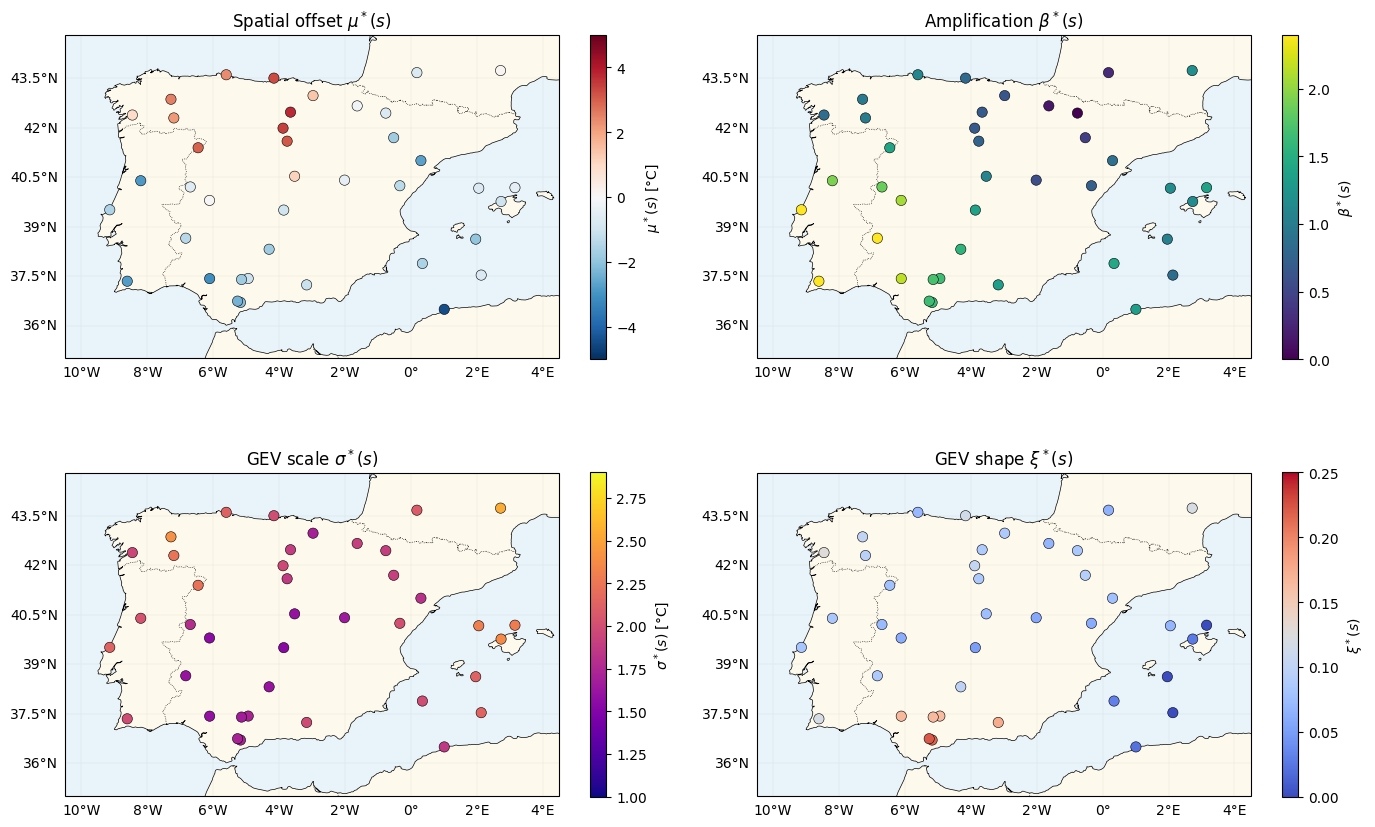

In [7]:
def plot_stations(ax, values, *, cmap: str, vlim: tuple, label: str) -> None:
    ax.set_extent(
        [SPAIN_BBOX[0] - 1, SPAIN_BBOX[1] + 1, SPAIN_BBOX[2] - 1, SPAIN_BBOX[3] + 1],
        crs=ccrs.PlateCarree(),
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f3fa")
    ax.add_feature(cfeature.LAND, facecolor="#fdf9ec")
    sc = ax.scatter(
        np.asarray(lon_st), np.asarray(lat_st),
        c=np.asarray(values), cmap=cmap, vmin=vlim[0], vmax=vlim[1],
        s=55, edgecolors="k", linewidths=0.4,
        transform=ccrs.PlateCarree(), zorder=5,
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(sc, ax=ax, shrink=0.75, label=label)


fig = plt.figure(figsize=(14, 9))
specs = [
    (1, mu_truth, "RdBu_r", (-5, 5), r"$\mu^*(s)$ [°C]", r"Spatial offset $\mu^*(s)$"),
    (2, beta_truth, "viridis", (0.0, 2.4), r"$\beta^*(s)$", r"Amplification $\beta^*(s)$"),
    (3, sigma_truth, "plasma", (1.0, 2.9), r"$\sigma^*(s)$ [°C]", r"GEV scale $\sigma^*(s)$"),
    (4, xi_truth, "coolwarm", (0.0, 0.25), r"$\xi^*(s)$", r"GEV shape $\xi^*(s)$"),
]
for idx, vals, cmap, vlim, label, title in specs:
    ax = fig.add_subplot(2, 2, idx, projection=ccrs.PlateCarree())
    plot_stations(ax, vals, cmap=cmap, vlim=vlim, label=label)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Kernel + variational factor classes

In [8]:
class MaternLite(eqx.Module):
    log_variance: Float[Array, ""]
    log_lengthscale: Float[Array, ""]

    @classmethod
    def init(cls, variance=1.0, lengthscale=1.0):
        return cls(
            log_variance=jnp.log(jnp.asarray(variance)),
            log_lengthscale=jnp.log(jnp.asarray(lengthscale)),
        )

    def __call__(self, X1, X2):
        return matern_kernel(
            X1, X2, jnp.exp(self.log_variance), jnp.exp(self.log_lengthscale), nu=1.5
        )


def _tril(L):
    tri = jnp.tril(L, k=-1)
    diag = jax.nn.softplus(jnp.diag(L))
    return tri + jnp.diag(diag)


class VariationalFactor(eqx.Module):
    mean: Float[Array, " N"]
    raw_L: Float[Array, "N N"]

    @classmethod
    def init(cls, n: int, scale: float = 0.3) -> "VariationalFactor":
        raw_L = jnp.eye(n) * jnp.log(jnp.expm1(jnp.asarray(scale)))
        return cls(mean=jnp.zeros(n), raw_L=raw_L)

    @property
    def L(self):
        return _tril(self.raw_L)

    @property
    def cov(self):
        L = self.L
        return L @ L.T

    @property
    def variance_diag(self):
        L = self.L
        return jnp.sum(L * L, axis=-1)

## Model — four trainable spatial GPs

A 4-way mean-field posterior over the $S$ stations, plus four scalar intercepts. Note how compact the class still is: the only cost of going from nb 02's two GPs to four is a couple more `MaternLite`/`VariationalFactor` slots.

In [9]:
class Model(eqx.Module):
    k_mu: MaternLite
    k_beta: MaternLite
    k_sig: MaternLite
    k_xi: MaternLite
    q_mu: VariationalFactor
    q_beta: VariationalFactor
    q_sig: VariationalFactor
    q_xi: VariationalFactor
    mu0: Float[Array, ""]
    beta0: Float[Array, ""]
    logsig0: Float[Array, ""]
    xi0: Float[Array, ""]
    jitter: float = eqx.field(static=True, default=1e-4)

    @classmethod
    def init(
        cls,
        S: int,
        *,
        mu0_init: float = 30.0,
        beta0_init: float = 1.0,
        sigma_init: float = 2.0,
        xi_init: float = 0.05,
    ) -> "Model":
        return cls(
            k_mu=MaternLite.init(variance=1.0, lengthscale=3.0),
            k_beta=MaternLite.init(variance=0.2, lengthscale=3.0),
            k_sig=MaternLite.init(variance=0.05, lengthscale=3.0),
            k_xi=MaternLite.init(variance=0.003, lengthscale=3.0),
            q_mu=VariationalFactor.init(S, scale=0.5),
            q_beta=VariationalFactor.init(S, scale=0.3),
            q_sig=VariationalFactor.init(S, scale=0.1),
            q_xi=VariationalFactor.init(S, scale=0.05),
            mu0=jnp.asarray(mu0_init),
            beta0=jnp.asarray(beta0_init),
            logsig0=jnp.log(jnp.asarray(sigma_init)),
            xi0=jnp.asarray(xi_init),
        )

    def _K(self, kernel, X):
        K = kernel(X, X) + self.jitter * jnp.eye(X.shape[0])
        return lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)

## ELBO — 4-term KL + 3-D Gauss–Hermite ELL

In [10]:
def kl_factor(q: VariationalFactor, K_prior_op):
    zeros = jnp.zeros_like(q.mean)
    q_cov = lx.MatrixLinearOperator(q.cov, lx.positive_semidefinite_tag)
    return gaussx.dist_kl_divergence(q.mean, q_cov, zeros, K_prior_op)


# Order-8 3-D Gauss-Hermite: 8^3 = 512 nodes per (s, t); tensor-produced inside gaussx.
_GH3 = gaussx.GaussHermiteIntegrator(order=8)


def ell_point(
    m_tau, v_tau,
    m_logsig, v_logsig,
    m_xi, v_xi,
    y,
):
    r"""$\mathbb{E}_q[\log \mathrm{GEV}(y \mid \tau, e^{\log\sigma}, \xi)]$ for one $(s, t)$.

    q factorises as a 3-D diagonal Gaussian over (tau, log_sigma, xi); gaussx tensor-products
    the per-axis quadrature nodes and sums.
    """
    mean3 = jnp.stack([m_tau, m_logsig, m_xi])
    var3 = jnp.stack([v_tau, v_logsig, v_xi])
    cov3 = jnp.diag(var3)
    state = gaussx.GaussianState(
        mean=mean3,
        cov=lx.MatrixLinearOperator(cov3, lx.positive_semidefinite_tag),
    )

    def log_lik(f):
        return GeneralizedExtremeValue(
            loc=f[0], scale=jnp.exp(f[1]), shape=f[2]
        ).log_prob(y)

    return gaussx.log_likelihood_expectation(log_lik, state, _GH3)


def total_ell(model: Model, d_vec, y):
    # Per-station posterior marginals (constant across time for sigma, xi)
    m_mu_s = model.q_mu.mean
    v_mu_s = model.q_mu.variance_diag
    m_b_s = model.beta0 + model.q_beta.mean           # (S,)
    v_b_s = model.q_beta.variance_diag                # (S,)
    m_sig_s = model.logsig0 + model.q_sig.mean        # (S,)
    v_sig_s = model.q_sig.variance_diag               # (S,)
    m_xi_s = model.xi0 + model.q_xi.mean              # (S,)
    v_xi_s = model.q_xi.variance_diag                 # (S,)

    # tau marginal on the grid
    m_tau = model.mu0 + m_mu_s[:, None] + m_b_s[:, None] * d_vec[None, :]   # (S, T)
    v_tau = v_mu_s[:, None] + v_b_s[:, None] * (d_vec ** 2)[None, :]        # (S, T)

    # Broadcast sigma/xi marginals across the T axis
    m_logsig = jnp.broadcast_to(m_sig_s[:, None], (S, T))
    v_logsig = jnp.broadcast_to(v_sig_s[:, None], (S, T))
    m_xi_b = jnp.broadcast_to(m_xi_s[:, None], (S, T))
    v_xi_b = jnp.broadcast_to(v_xi_s[:, None], (S, T))

    ell_vmapped = jax.vmap(
        jax.vmap(ell_point, in_axes=(0, 0, 0, 0, 0, 0, 0)),
        in_axes=(0, 0, 0, 0, 0, 0, 0),
    )
    return jnp.sum(ell_vmapped(m_tau, v_tau, m_logsig, v_logsig, m_xi_b, v_xi_b, y))


def neg_elbo(model: Model, X_s, d_vec, y):
    kl = (
        kl_factor(model.q_mu, model._K(model.k_mu, X_s))
        + kl_factor(model.q_beta, model._K(model.k_beta, X_s))
        + kl_factor(model.q_sig, model._K(model.k_sig, X_s))
        + kl_factor(model.q_xi, model._K(model.k_xi, X_s))
    )
    return kl - total_ell(model, d_vec, y)

## Training

Longer run than nb 02 (3000 steps) — the 3-D quadrature is noisier in its gradient signal for the tail fields because $\xi$ affects every GEV log-prob non-linearly. Gradient clipping keeps the first few hundred steps stable while the four intercepts settle.

In [11]:
model = Model.init(
    S=S,
    mu0_init=float(jnp.mean(y_obs)),
    beta0_init=1.0,
    sigma_init=2.0,
    xi_init=0.05,
)
optimiser = optax.chain(optax.clip_by_global_norm(5.0), optax.adam(5e-3))
opt_state = optimiser.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(model, opt_state):
    loss, grads = eqx.filter_value_and_grad(neg_elbo)(model, stations, d_vec, y_obs)
    updates, opt_state = optimiser.update(grads, opt_state, model)
    return eqx.apply_updates(model, updates), opt_state, loss


n_steps = 3000
losses: list[float] = []
for _ in range(n_steps):
    model, opt_state, loss = train_step(model, opt_state)
    losses.append(float(loss))

beta_post = model.beta0 + model.q_beta.mean
sig_post = jnp.exp(model.logsig0 + model.q_sig.mean)
xi_post = model.xi0 + model.q_xi.mean

print(f"final -ELBO         = {losses[-1]:.2f}")
print(f"fitted mu0          = {float(model.mu0):.2f}     (truth {TRUTH['mu0']:.2f})")
print(f"fitted beta0        = {float(model.beta0):.3f}    (truth mean beta* {float(beta_truth.mean()):.3f})")
print(f"fitted logsig0      = {float(model.logsig0):.3f}   (truth {float(TRUTH['logsig0']):.3f})")
print(f"fitted xi0          = {float(model.xi0):.3f}    (truth {TRUTH['xi0']:.3f})")
print(f"fitted sigma(s) rng = [{float(sig_post.min()):.2f}, {float(sig_post.max()):.2f}] °C  "
      f"(truth [{float(sigma_truth.min()):.2f}, {float(sigma_truth.max()):.2f}])")
print(f"fitted xi(s) range  = [{float(xi_post.min()):.3f}, {float(xi_post.max()):.3f}]  "
      f"(truth [{float(xi_truth.min()):.3f}, {float(xi_truth.max()):.3f}])")

final -ELBO         = 3701.30
fitted mu0          = 34.39     (truth 35.00)
fitted beta0        = 1.454    (truth mean beta* 1.235)
fitted logsig0      = 0.674   (truth 0.588)
fitted xi0          = 0.099    (truth 0.120)
fitted sigma(s) rng = [1.52, 2.47] °C  (truth [1.53, 2.54])
fitted xi(s) range  = [0.092, 0.109]  (truth [-0.012, 0.223])


### Loss curve

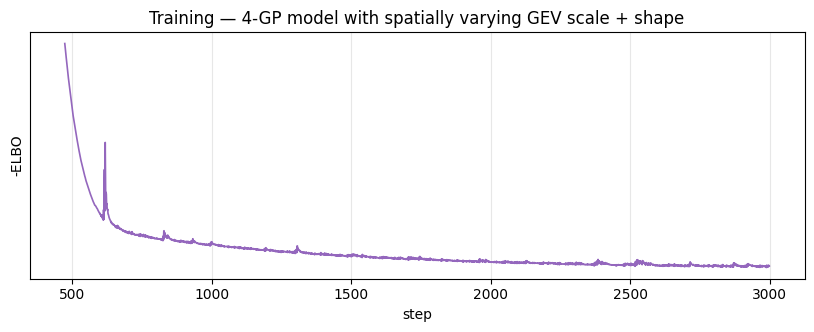

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(losses, "C4-", lw=1.2)
ax.set_xlabel("step")
ax.set_ylabel("-ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("Training — 4-GP model with spatially varying GEV scale + shape")
ax.grid(alpha=0.3, which="both")
plt.show()

## Parameter recovery — four rows, four fields

Each row: truth map, posterior-mean map, per-station scatter with $\pm 2\sigma$ posterior. The $\xi$ row is the hardest — tails are information-poor with 40 annual maxima per station, so expect substantial posterior shrinkage toward $\xi_0$.

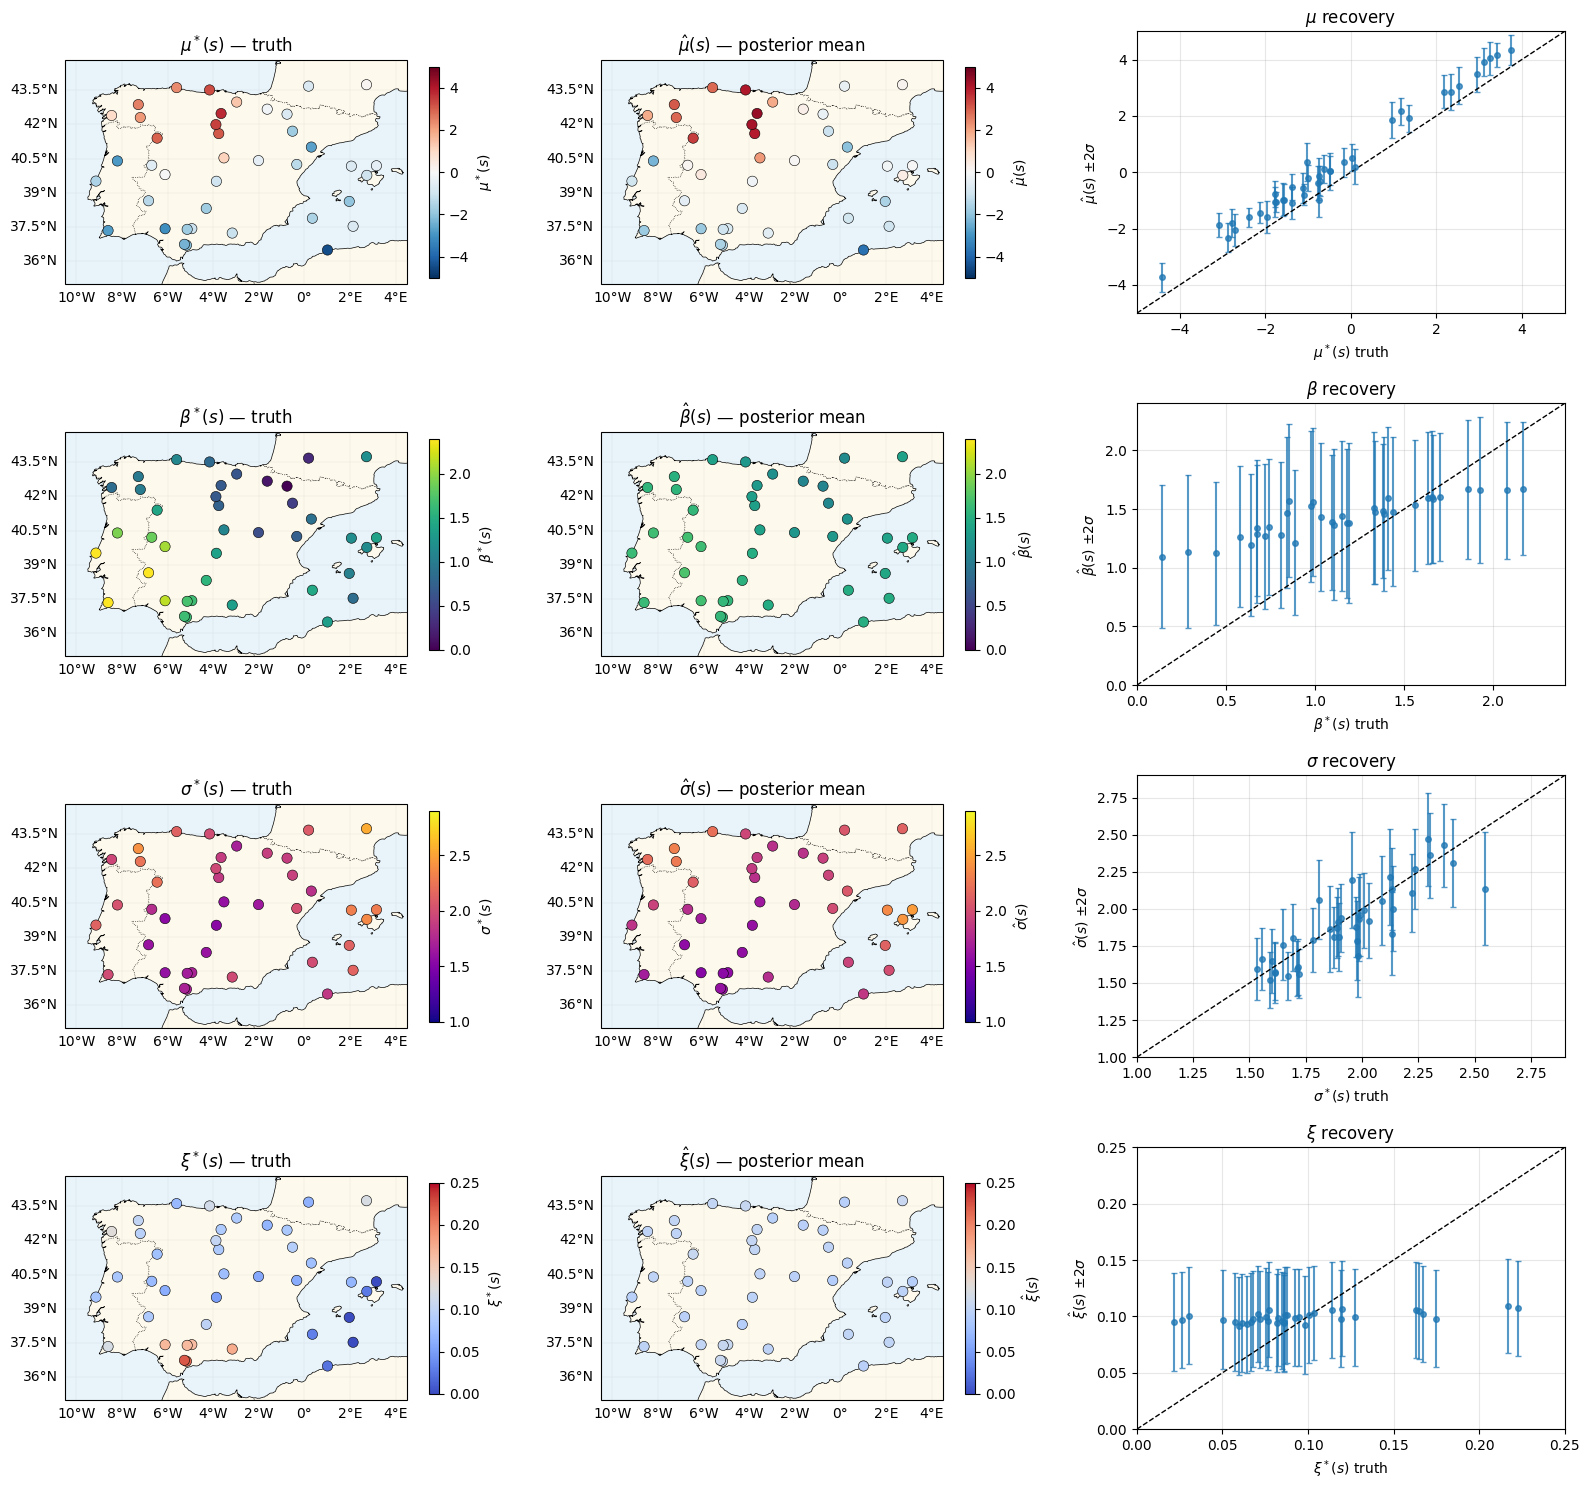

In [13]:
mu_mean = model.q_mu.mean
mu_std = jnp.sqrt(model.q_mu.variance_diag)
beta_mean = model.beta0 + model.q_beta.mean
beta_std = jnp.sqrt(model.q_beta.variance_diag)
sig_mean = jnp.exp(model.logsig0 + model.q_sig.mean)
# sigma posterior std via delta-method: Var(exp(X)) ≈ exp(2m) Var(X) for small Var(X)
sig_std = sig_mean * jnp.sqrt(model.q_sig.variance_diag)
xi_mean = model.xi0 + model.q_xi.mean
xi_std = jnp.sqrt(model.q_xi.variance_diag)

rows = [
    (r"$\mu$",    r"$\mu^*(s)$",    r"$\hat\mu(s)$",    mu_truth,    mu_mean,   mu_std,   "RdBu_r",   (-5, 5)),
    (r"$\beta$",  r"$\beta^*(s)$",  r"$\hat\beta(s)$",  beta_truth,  beta_mean, beta_std, "viridis",  (0.0, 2.4)),
    (r"$\sigma$", r"$\sigma^*(s)$", r"$\hat\sigma(s)$", sigma_truth, sig_mean,  sig_std,  "plasma",   (1.0, 2.9)),
    (r"$\xi$",    r"$\xi^*(s)$",    r"$\hat\xi(s)$",    xi_truth,    xi_mean,   xi_std,   "coolwarm", (0.0, 0.25)),
]

fig = plt.figure(figsize=(16, 15))
for r, (short, truth_lab, post_lab, truth_v, post_m, post_s, cmap, vlim) in enumerate(rows):
    ax = fig.add_subplot(4, 3, 3 * r + 1, projection=ccrs.PlateCarree())
    plot_stations(ax, truth_v, cmap=cmap, vlim=vlim, label=truth_lab)
    ax.set_title(truth_lab + " — truth")

    ax = fig.add_subplot(4, 3, 3 * r + 2, projection=ccrs.PlateCarree())
    plot_stations(ax, post_m, cmap=cmap, vlim=vlim, label=post_lab)
    ax.set_title(post_lab + " — posterior mean")

    ax = fig.add_subplot(4, 3, 3 * r + 3)
    ax.errorbar(
        np.asarray(truth_v), np.asarray(post_m), yerr=2 * np.asarray(post_s),
        fmt="o", ms=4, alpha=0.75, capsize=2,
    )
    lo, hi = vlim
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(truth_lab + " truth")
    ax.set_ylabel(post_lab + r" $\pm 2\sigma$")
    ax.set_title(short + " recovery")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Return-level maps with location-dependent tails

The per-station return level inverts the location-specific GEV:

$$z_p(s, t^*) = \hat\tau(s, t^*) + \frac{\hat\sigma(s)}{\hat\xi(s)} \Bigl\{\bigl[-\log(1 - p)\bigr]^{-\hat\xi(s)} - 1\Bigr\}.$$

Note what's new vs nb 02: $\hat\sigma$ and $\hat\xi$ now carry a spatial index too. Locations with high $\hat\xi(s)$ see heavier tails, so the 100-yr return level sits further above the 25-yr level than a constant-$\xi$ model would predict.

GMST 2024 = 0.848 °C, GMST 2050 (extrap) = 1.398 °C
100-yr return shift 2024->2050:  mean 0.79 °C,  range [0.60, 0.94] °C
100yr - 25yr gap (2024):         mean 3.93 °C,  range [3.17, 4.97] °C  (spread driven by xi(s), sigma(s))


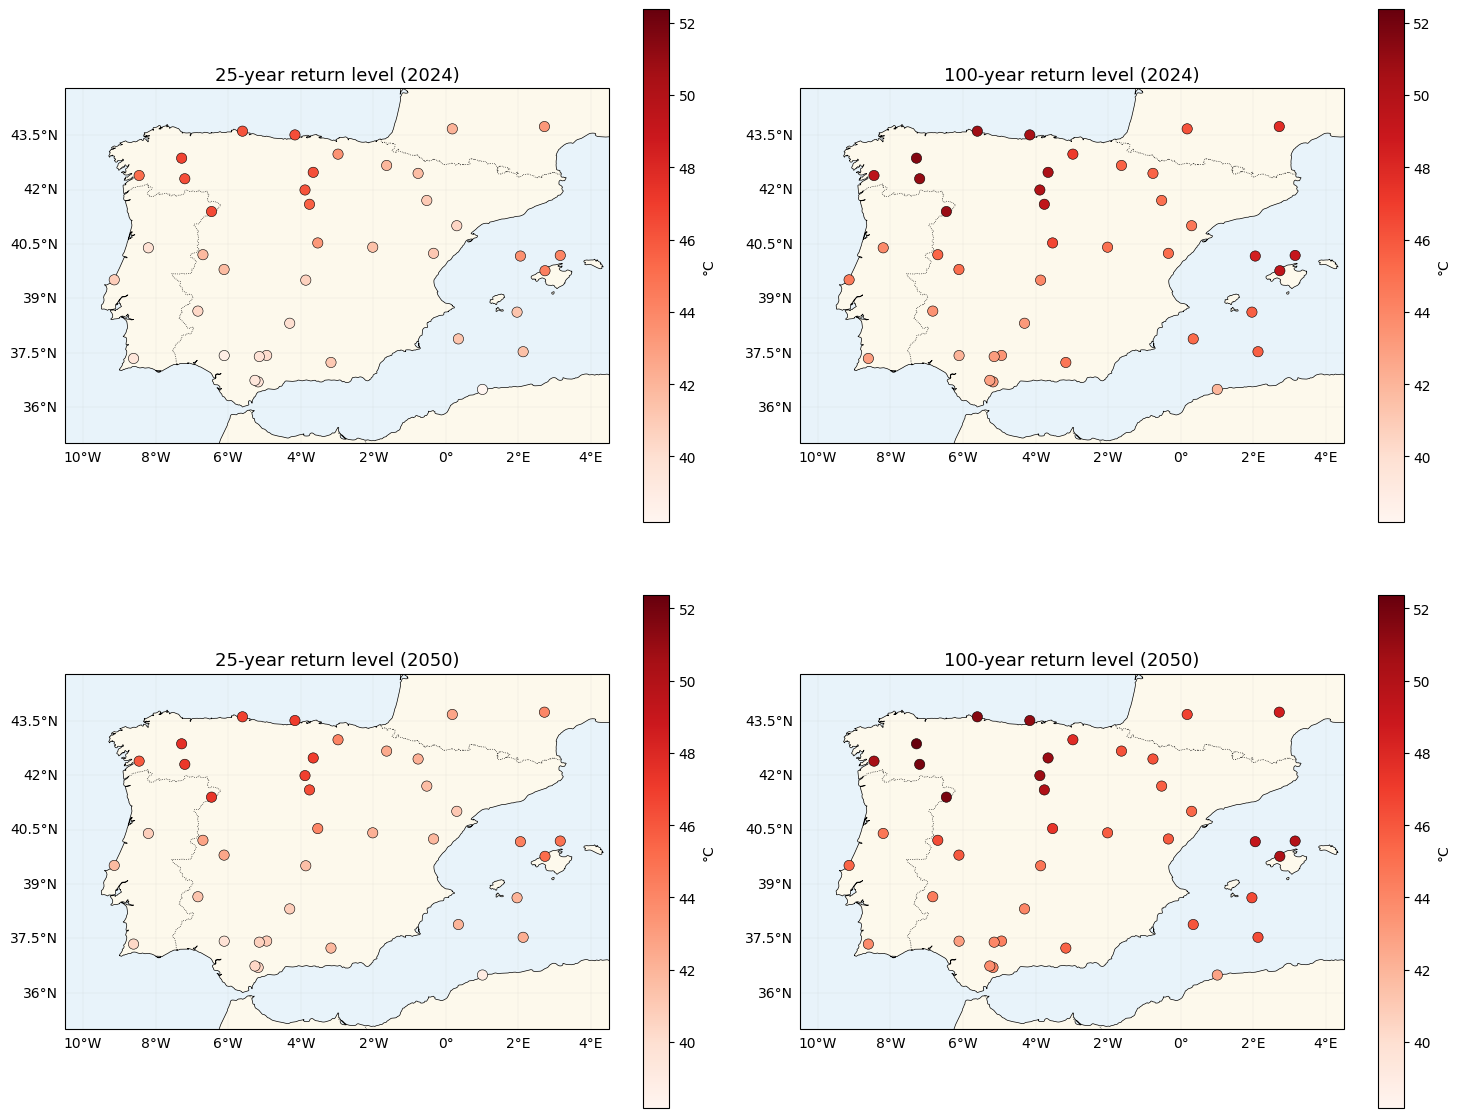

In [14]:
def gev_return_level(mu_loc, sigma, xi, return_period):
    p = 1.0 / return_period
    safe_xi = jnp.where(jnp.abs(xi) < 1e-6, 1.0, xi)
    gev_q = mu_loc + sigma * ((-jnp.log1p(-p)) ** (-safe_xi) - 1.0) / safe_xi
    gumbel_q = mu_loc - sigma * jnp.log(-jnp.log1p(-p))
    return jnp.where(jnp.abs(xi) < 1e-6, gumbel_q, gev_q)


def predictive_tau(model: Model, gmst_star):
    d_star = gmst_star - jnp.mean(gmst)
    beta_s = model.beta0 + model.q_beta.mean
    return model.mu0 + model.q_mu.mean + beta_s * d_star


gmst_2024 = gmst[-1]
gmst_trend_per_year = (gmst[-1] - gmst[0]) / (T - 1)
gmst_2050 = gmst_2024 + gmst_trend_per_year * (2050 - (YEAR_0 + T - 1))

tau_2024 = predictive_tau(model, gmst_2024)
tau_2050 = predictive_tau(model, gmst_2050)

z25_2024 = gev_return_level(tau_2024, sig_post, xi_post, 25)
z100_2024 = gev_return_level(tau_2024, sig_post, xi_post, 100)
z25_2050 = gev_return_level(tau_2050, sig_post, xi_post, 25)
z100_2050 = gev_return_level(tau_2050, sig_post, xi_post, 100)
shift_100 = z100_2050 - z100_2024
gap_100_25 = z100_2024 - z25_2024   # tail thickness proxy: gap scales with sigma/xi

vmin = float(jnp.min(jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])))
vmax = float(jnp.max(jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])))
print(f"GMST 2024 = {float(gmst_2024):.3f} °C, GMST 2050 (extrap) = {float(gmst_2050):.3f} °C")
print(f"100-yr return shift 2024->2050:  mean {float(jnp.mean(shift_100)):.2f} °C,  "
      f"range [{float(shift_100.min()):.2f}, {float(shift_100.max()):.2f}] °C")
print(f"100yr - 25yr gap (2024):         mean {float(jnp.mean(gap_100_25)):.2f} °C,  "
      f"range [{float(gap_100_25.min()):.2f}, {float(gap_100_25.max()):.2f}] °C  "
      f"(spread driven by xi(s), sigma(s))")

fig, axes = plt.subplots(2, 2, figsize=(15, 13), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, values, title in zip(
    axes.flat,
    [z25_2024, z100_2024, z25_2050, z100_2050],
    ["25-year return level (2024)", "100-year return level (2024)",
     "25-year return level (2050)", "100-year return level (2050)"],
    strict=True,
):
    plot_stations(ax, values, cmap="Reds", vlim=(vmin, vmax), label="°C")
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.show()

### The two spatial signatures — side by side

Two maps tell the story of where this model differs from nb 02:

1. **2024 $\to$ 2050 shift in the 100-year return** — unchanged from nb 02 in structure (depends on $\hat\beta(s)$), still tracks the spatial warming rate.
2. **Gap between 25-year and 100-year returns** — *new*, driven by the tail shape $\hat\xi(s) \cdot \hat\sigma(s)$. nb 02 would produce a constant map here; nb 03 produces a spatially varying one.

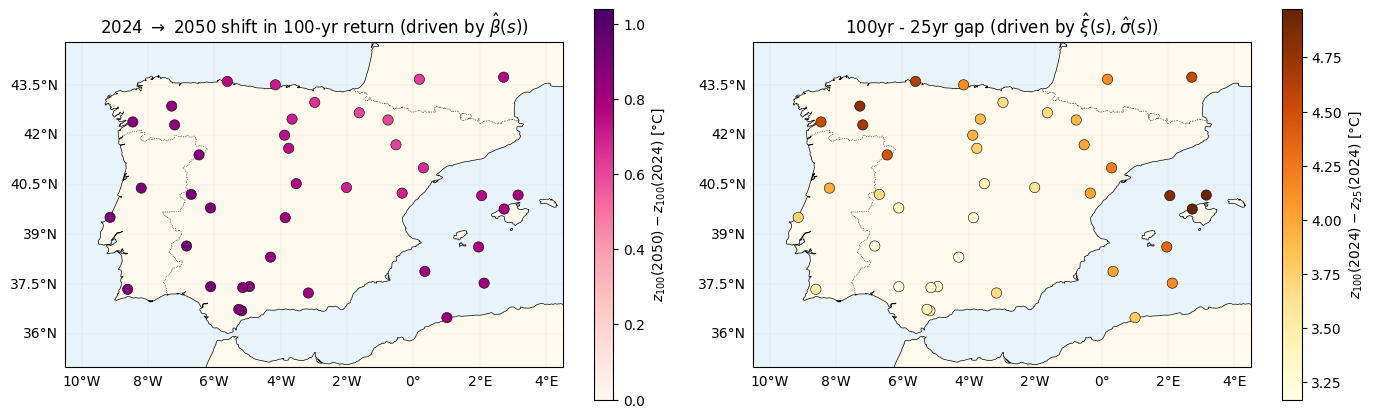

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), subplot_kw={"projection": ccrs.PlateCarree()})
plot_stations(
    axes[0], shift_100, cmap="RdPu", vlim=(0.0, 1.1 * float(jnp.max(jnp.abs(shift_100)))),
    label=r"$z_{100}(2050) - z_{100}(2024)$ [°C]",
)
axes[0].set_title(r"2024 $\to$ 2050 shift in 100-yr return (driven by $\hat\beta(s)$)")
plot_stations(
    axes[1], gap_100_25, cmap="YlOrBr", vlim=(float(gap_100_25.min()), float(gap_100_25.max())),
    label=r"$z_{100}(2024) - z_{25}(2024)$ [°C]",
)
axes[1].set_title(r"100yr - 25yr gap (driven by $\hat\xi(s), \hat\sigma(s)$)")
plt.tight_layout()
plt.show()

## Contrast with nb 02

| Aspect | nb 02 (multiplicative)                   | nb 03 (non-stationary tails)                          |
|---|---|---|
| Likelihood                | $\mathrm{GEV}(\tau(s,t),\, \sigma,\, \xi)$          | $\mathrm{GEV}(\tau(s,t),\, \sigma(s),\, \xi(s))$            |
| Spatial GPs               | 2 ($\mu, \tilde\beta$)                              | 4 ($\mu, \tilde\beta, \tilde\sigma, \tilde\xi$)            |
| Variational factors       | 2                                                  | 4 (all mean-field)                                         |
| ELL quadrature            | 1-D Gauss–Hermite, order 20                        | 3-D tensor-product Gauss–Hermite, order 8                 |
| Per-step ELL cost         | $S T \cdot 20 = 32$k log-prob evals                | $S T \cdot 8^3 = 820$k log-prob evals                    |
| 2024 $\to$ 2050 map       | $\propto \hat\beta(s)$                             | $\propto \hat\beta(s)$ (unchanged)                         |
| 100yr$-$25yr gap map      | constant                                           | spatially varying (depends on $\hat\sigma(s), \hat\xi(s)$) |

The key structural lesson: `gaussx.GaussHermiteIntegrator` generalises from 1-D to 3-D with zero code changes at the call site — the same `log_likelihood_expectation(log_lik, state, gh)` line handles both the nb 02 and nb 03 ELL. The work was all in rearranging the per-station latent moments so they feed a multivariate `GaussianState`.

## Summary

- Four parallel spatial GPs ($\mu, \tilde\beta, \tilde\sigma, \tilde\xi$) + four scalar intercepts + a 4-way mean-field posterior give a fully non-stationary GEV model at the same conceptual cost as nb 02.
- The ELL lifts from 1-D to 3-D Gauss–Hermite quadrature with no API change in `gaussx` — `GaussHermiteIntegrator(order=8)` on a 3-D `GaussianState` tensor-products automatically.
- $\xi(s)$ recovery is statistically hard (tails are information-poor with 40 years of data) and the posterior tends to shrink toward $\xi_0$ via the GP prior; the map still captures the broad spatial gradient of the truth.
- The 100-yr$-$25-yr gap map is the qualitative handle nb 03 adds: under a homogeneous-tail model (nb 02), this gap is constant across space; here it varies with the local $\hat\sigma(s), \hat\xi(s)$, which matters for stress-testing infrastructure in heavy-tailed regions.

### Follow-ups

- **Temporal non-stationarity** in $\sigma, \xi$: tie them to $d(t)$ through a rate parameter analogous to $\beta$, e.g. $\log\sigma(s, t) = \log\sigma_0 + \tilde\sigma(s) + \gamma(s) \cdot d(t)$. Same `SumKronecker` structure, one more spatial GP.
- **Hierarchical correlations**: replace the mean-field 4-way factorisation with a coregionalised LMC prior, so that $\mu, \tilde\beta, \tilde\sigma, \tilde\xi$ share information through a small task-kernel — shrinks the $\xi$ posterior by borrowing strength from the better-identified fields.
- **Cluster-aware priors**: replace the stationary Matern on $\tilde\xi$ with a non-stationary or mixture kernel capturing climate regimes (Atlantic / continental / Mediterranean) — useful when the spatial domain mixes qualitatively different climates.